##Dataset 5 — Wind & Solar Energy Production (Kaggle) (Yas)

In [ ]:
import pandas as pd

Fonte: https://www.kaggle.com/datasets/ahmeduzaki/wind-and-solar-energy-production-dataset

Situação

Um operador de um portfólio de fontes renováveis deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Como as duas fontes possuem escalas próprias, cada uma deverá ser comparada com o seu próprio valor máximo.

In [58]:
# 1. Carrega amostra do Orange
df5 = pd.read_csv('/content/Energy_Production_Amostra_20.csv')

display(df5.head())
print("Shape:", df5.shape)
df5.info()

,Date,Start_Hour,End_Hour,Source,Production
0,12/18/2022,21,22,Wind,11400
1,1/29/2024,14,15,Wind,7917
2,8/1/2024,15,16,Solar,8835
3,11/10/2020,1,2,Wind,989
4,12/19/2022,1,2,Wind,12526


Shape: (36305, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36305 entries, 0 to 36304
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        36305 non-null  object
 1   Start_Hour  36305 non-null  int64 
 2   End_Hour    36305 non-null  int64 
 3   Source      36305 non-null  object
 4   Production  36305 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.4+ MB


In [59]:
# 2. Separa as fontes e renomear variáveis

df_solar = df5[df5['Source'] == 'Solar'].copy()
df_eolica = df5[df5['Source'] == 'Wind'].copy()

df_solar.rename(columns={'Production': 'Geracao_Solar'}, inplace=True)
df_eolica.rename(columns={'Production': 'Geracao_Eolica'}, inplace=True)

print("Registros solares:", len(df_solar))
print("Registros eólicos:", len(df_eolica))

Registros solares: 6610
Registros eólicos: 29693


In [60]:
# 3. Máximos e respectivos limites de 70%

max_solar = df_solar['Geracao_Solar'].max()
max_eolica = df_eolica['Geracao_Eolica'].max()

limiar_solar_70 = 0.70 * max_solar
limiar_eolica_70 = 0.70 * max_eolica

print(f"Máximo Solar: {max_solar}")
print(f"70% do máximo Solar: {limiar_solar_70:.2f}")

print(f"Máximo Eólico: {max_eolica}")
print(f"70% do máximo Eólico: {limiar_eolica_70:.2f}")

Máximo Solar: 16578
70% do máximo Solar: 11604.60
Máximo Eólico: 23446
70% do máximo Eólico: 16412.20


In [61]:
# 4. DataFrames de alta geração

df_solar_alta = df_solar[
    df_solar['Geracao_Solar'] > limiar_solar_70
].copy()

df_eolica_alta = df_eolica[
    df_eolica['Geracao_Eolica'] > limiar_eolica_70
].copy()

print("Alta geração solar:", len(df_solar_alta))
print("Alta geração eólica:", len(df_eolica_alta))

Alta geração solar: 119
Alta geração eólica: 702


In [62]:
# 5. Percentuais dentro de cada fonte

qtd_solar = len(df_solar)
qtd_eolica = len(df_eolica)

qtd_solar_alta = len(df_solar_alta)
qtd_eolica_alta = len(df_eolica_alta)

pct_solar_alta = (qtd_solar_alta / qtd_solar) * 100
pct_eolica_alta = (qtd_eolica_alta / qtd_eolica) * 100

print(f"Solar: {qtd_solar_alta} de {qtd_solar} registros ({pct_solar_alta:.2f}%)")
print(f"Eólica: {qtd_eolica_alta} de {qtd_eolica} registros ({pct_eolica_alta:.2f}%)")

Solar: 119 de 6610 registros (1.80%)
Eólica: 702 de 29693 registros (2.36%)


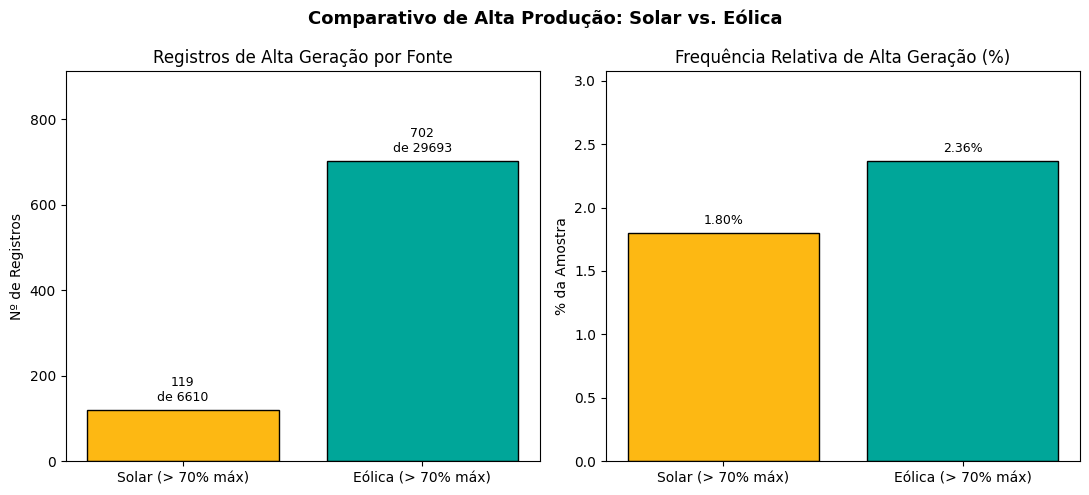

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

fontes = ['Solar (> 70% máx)', 'Eólica (> 70% máx)']
qtds = [qtd_solar_alta, qtd_eolica_alta]
pcts = [pct_solar_alta, pct_eolica_alta]
cores = ['#FDB813', '#00A699']

total_source_records = [qtd_solar, qtd_eolica]

# Gráfico 1: qtde de Registros
bars1 = axes[0].bar(fontes, qtds, color=cores, edgecolor='black')
axes[0].set_ylabel('Nº de Registros')
axes[0].set_title('Registros de Alta Geração por Fonte')
axes[0].set_ylim(0, max(qtds) * 1.3 if max(qtds) > 0 else 10)
for b, v_alta, v_total in zip(bars1, qtds, total_source_records):
    axes[0].text(b.get_x() + b.get_width()/2, v_alta + (max(qtds)*0.02 if max(qtds) > 0 else 0.2),
                 f'{v_alta}\nde {v_total}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Percentual da Amostra
bars2 = axes[1].bar(fontes, pcts, color=cores, edgecolor='black')
axes[1].set_ylabel('% da Amostra')
axes[1].set_title('Frequência Relativa de Alta Geração (%)')
axes[1].set_ylim(0, max(pcts) * 1.3 if max(pcts) > 0 else 10)
for b, v in zip(bars2, pcts):
    axes[1].text(b.get_x() + b.get_width()/2, v + (max(pcts)*0.02 if max(pcts) > 0 else 0.2),
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Comparativo de Alta Produção: Solar vs. Eólica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()